In [18]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import os
import warnings

warnings.filterwarnings("ignore")

## <VAR 모델>

## Q. realgdp와 realcons를 이용하여 VAR 모델을 추정하고, 변수들 간의 상호작용을 분석하시오.

In [19]:
from statsmodels.api import datasets

data = datasets.macrodata.load_pandas().data
data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


In [20]:
## 원본데이터
data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


In [21]:
### 결측치 확인
data.isnull().sum()

year        0
quarter     0
realgdp     0
realcons    0
realinv     0
realgovt    0
realdpi     0
cpi         0
m1          0
tbilrate    0
unemp       0
pop         0
infl        0
realint     0
dtype: int64

In [22]:
### 시계열 전처리
data["year"] = pd.to_datetime(data["year"], format="%Y")
data = data.set_index("year")          ### year 컬럼을 index로
data

,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
year,,,,,,,,,,,,,
1959-01-01,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1959-01-01,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
1959-01-01,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
1959-01-01,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
1960-01-01,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008-01-01,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
2008-01-01,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
2009-01-01,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71


In [23]:
### 종속변수 2개 컬럼만 필터링
df_temp = data[["realgdp", "realcons"]].copy()
df_temp

,realgdp,realcons
year,,
1959-01-01,2710.349,1707.4
1959-01-01,2778.801,1733.7
1959-01-01,2775.488,1751.8
1959-01-01,2785.204,1753.7
1960-01-01,2847.699,1770.5
...,...,...
2008-01-01,13324.600,9267.7
2008-01-01,13141.920,9195.3
2009-01-01,12925.410,9209.2


In [24]:
### 데이터 분할 (train 170개, test 33개)

train = df_temp.iloc[:170, :]
test = df_temp.iloc[170:, :]

In [25]:
### 정상성 여부 확인 (realgdp)
from statsmodels.tsa.stattools import adfuller

# H0 : 시계열에 단위근이 존재한다. (=비정상 시계열)
# H1 : 시계열에 단위근이 존재하지 않는다. (=정상 시계열)

result = adfuller(train["realgdp"])

s = result[0]
p = result[1]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.9989801598345119
귀무가설 채택


In [26]:
### 정상성 여부 확인 (realcons)
from statsmodels.tsa.stattools import adfuller

# H0 : 시계열에 단위근이 존재한다. (=비정상 시계열)
# H1 : 시계열에 단위근이 존재하지 않는다. (=정상 시계열)

result = adfuller(train["realcons"])

s = result[0]
p = result[1]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.9988553448252179
귀무가설 채택


In [27]:
print("""
realgdp, realcons 모두 비정상 시계열이다.
""")


realgdp, realcons 모두 비정상 시계열이다.



In [28]:
### realgdp 컬럼 1차분

train["realgdp_diff"] = train["realgdp"].diff()
train

,realgdp,realcons,realgdp_diff
year,,,
1959-01-01,2710.349,1707.4,NaN
1959-01-01,2778.801,1733.7,68.452
1959-01-01,2775.488,1751.8,-3.313
1959-01-01,2785.204,1753.7,9.716
1960-01-01,2847.699,1770.5,62.495
...,...,...,...
2000-01-01,11258.454,7571.8,215.410
2000-01-01,11267.867,7645.9,9.413
2000-01-01,11334.544,7713.5,66.677


In [29]:
### 정상성 여부 재확인 (realgdp)
from statsmodels.tsa.stattools import adfuller

# H0 : 시계열에 단위근이 존재한다. (=비정상 시계열)
# H1 : 시계열에 단위근이 존재하지 않는다. (=정상 시계열)

result = adfuller(train["realgdp_diff"].dropna())

s = result[0]
p = result[1]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 6.748984598396614e-07
귀무가설 기각


In [30]:
### realcons 컬럼 1차분

train["realcons_diff"] = train["realcons"].diff()
train

,realgdp,realcons,realgdp_diff,realcons_diff
year,,,,
1959-01-01,2710.349,1707.4,NaN,NaN
1959-01-01,2778.801,1733.7,68.452,26.3
1959-01-01,2775.488,1751.8,-3.313,18.1
1959-01-01,2785.204,1753.7,9.716,1.9
1960-01-01,2847.699,1770.5,62.495,16.8
...,...,...,...,...
2000-01-01,11258.454,7571.8,215.410,70.5
2000-01-01,11267.867,7645.9,9.413,74.1
2000-01-01,11334.544,7713.5,66.677,67.6


In [31]:
### 정상성 여부 재확인 (realcons)
from statsmodels.tsa.stattools import adfuller

# H0 : 시계열에 단위근이 존재한다. (=비정상 시계열)
# H1 : 시계열에 단위근이 존재하지 않는다. (=정상 시계열)

result = adfuller(train["realcons_diff"].dropna())

s = result[0]
p = result[1]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.007421001377992412
귀무가설 기각


In [32]:
print("""
차분을 통해 realgdp, realcons 모두 정상시계열이다.
""")


차분을 통해 realgdp, realcons 모두 정상시계열이다.



In [33]:
train

,realgdp,realcons,realgdp_diff,realcons_diff
year,,,,
1959-01-01,2710.349,1707.4,NaN,NaN
1959-01-01,2778.801,1733.7,68.452,26.3
1959-01-01,2775.488,1751.8,-3.313,18.1
1959-01-01,2785.204,1753.7,9.716,1.9
1960-01-01,2847.699,1770.5,62.495,16.8
...,...,...,...,...
2000-01-01,11258.454,7571.8,215.410,70.5
2000-01-01,11267.867,7645.9,9.413,74.1
2000-01-01,11334.544,7713.5,66.677,67.6


In [34]:
### VAR 모델 적합
from statsmodels.tsa.statespace.varmax import VARMAX
import itertools

# 탐색할 차수 범위
p = range(0, 6)    # p 차수
q = [0]            # q 차수

results = []

for order in itertools.product(p, q):
    try:
        model = VARMAX(train[["realgdp_diff", "realcons_diff"]].dropna(),   ## 정상시계열 데이터만 넣기
                       order=order                                          # p, q 차수
                       ).fit()
        
        results.append({
                        "order" : order,
                        "AIC" : model.aic
                       })
    except Exception:
        continue

# DataFrame으로 정리
df_results = pd.DataFrame(results)
df_results

,order,AIC
0,"(1, 0)",3320.168966
1,"(2, 0)",3311.405471
2,"(3, 0)",3295.458951
3,"(4, 0)",3302.428071
4,"(5, 0)",3304.881371


In [35]:
### 그레인저 인과관계 검정 (realcons => realgdp)
from statsmodels.tsa.stattools import grangercausalitytests

# H0 : realdpi는 realcons에 그레인저 인과관계가 없다.
# H1 : realdpi는 realcons에 그레인저 인과관계가 있다.

## 최적 차수(p)값 넣기
maxlag = 3

result = grangercausalitytests(train[["realgdp_diff", "realcons_diff"]].dropna(),   ## 정상 시계열만 넣기
                               maxlag=maxlag,             ## 최적 차수(p)값
                               verbose=False             ## 검정 과정 출력 안하기(False)
                               )
p = result[maxlag][0]["ssr_ftest"][1]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 7.761604600459423e-08
귀무가설 기각


In [36]:
### 그레인저 인과관계 검정 (realgdp => realcons)
from statsmodels.tsa.stattools import grangercausalitytests

# H0 : realdpi는 realcons에 그레인저 인과관계가 없다.
# H1 : realdpi는 realcons에 그레인저 인과관계가 있다.

## 최적 차수(p)값 넣기
maxlag = 3

result = grangercausalitytests(train[["realcons_diff", "realgdp_diff"]].dropna(),   ## 정상 시계열만 넣기
                               maxlag=maxlag,             ## 최적 차수(p)값
                               verbose=False             ## 검정 과정 출력 안하기(False)
                               )
p = result[maxlag][0]["ssr_ftest"][1]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.37299597550941793
귀무가설 채택


In [37]:
### VAR 모델 적합
from statsmodels.tsa.statespace.varmax import VARMAX

model = VARMAX(train[["realgdp_diff", "realcons_diff"]].dropna(),   ## 정상시계열 데이터만 넣기
               order=(3,0)                                          # p, q 차수
               ).fit()
model.summary()

Dep. Variable:,"['realgdp_diff', 'realcons_diff']",No. Observations:,169
Model:,VAR(3),Log Likelihood,-1630.729
,+ intercept,AIC,3295.459
Date:,"Fri, 29 Aug 2025",BIC,3348.667
Time:,21:03:06,HQIC,3317.052
Sample:,0,,
,- 169,,
Covariance Type:,opg,,
Ljung-Box (L1) (Q):,"0.00, 0.00",Jarque-Bera (JB):,"8.37, 2.88"
Prob(Q):,"1.00, 0.97",Prob(JB):,"0.02, 0.24"
Heteroskedasticity (H):,"1.83, 3.25",Skew:,"0.09, 0.06"


In [38]:
## 잔차분석

In [39]:
### 잔차의 독립성 (realgdp 변수)
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model.resid["realgdp_diff"]

result = acorr_ljungbox(residuals)
result

,lb_stat,lb_pvalue
1,0.000003,0.998727
2,0.030412,0.984909
3,0.030675,0.998584
4,0.136606,0.997771
5,1.702196,0.888623
6,2.071377,0.913018
7,3.159884,0.869828
8,4.442703,0.815138
9,5.327454,0.804880
10,5.443599,0.859647


In [40]:
### 잔차의 독립성 (realcons 변수)
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model.resid["realcons_diff"]

result = acorr_ljungbox(residuals)
result

,lb_stat,lb_pvalue
1,0.011862,0.913270
2,0.030558,0.984837
3,0.046803,0.997345
4,0.052205,0.999665
5,0.054561,0.999964
6,0.793905,0.992236
7,0.805284,0.997390
8,2.754017,0.948834
9,2.814338,0.971203
10,2.826470,0.985218


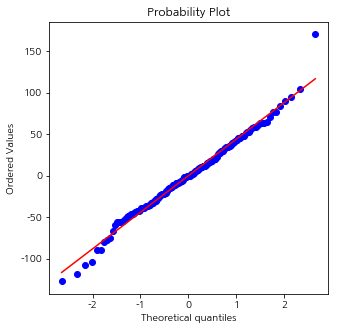

In [41]:
### 잔차의 정규성 (realgdp)
from scipy.stats import probplot

residuals = model.resid["realgdp_diff"]

plt.figure(figsize=(5,5))

probplot(residuals, dist="norm", plot=plt)

plt.show()

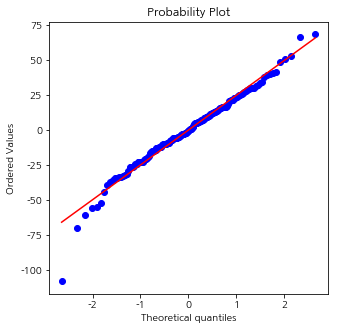

In [42]:
### 잔차의 정규성 (realcons)
from scipy.stats import probplot

residuals = model.resid["realcons_diff"]

plt.figure(figsize=(5,5))

probplot(residuals, dist="norm", plot=plt)

plt.show()

In [43]:
### 잔차의 등분산성 (realgdp)
from statsmodels.stats.diagnostic import het_arch

# H0 : 잔차가 등분산성을 만족한다.
# H1 : 잔차가 등분산성을 만족하지 않는다.

residuals = model.resid["realgdp_diff"]

s, p, fstat, f_pvalue = het_arch(residuals)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.2554868525915154
귀무가설 채택


In [44]:
### 잔차의 등분산성 (realcons)
from statsmodels.stats.diagnostic import het_arch

# H0 : 잔차가 등분산성을 만족한다.
# H1 : 잔차가 등분산성을 만족하지 않는다.

residuals = model.resid["realcons_diff"]

s, p, fstat, f_pvalue = het_arch(residuals)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.9225932982473258
귀무가설 채택


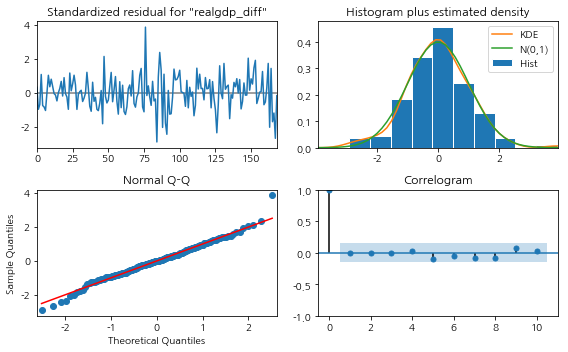

In [45]:
### realgdp의 잔차 분석 시각화
model.plot_diagnostics(figsize=(8,5), variable=0)      ## 첫번째 변수(variable=0)의 잔차분석

plt.tight_layout()
plt.show()

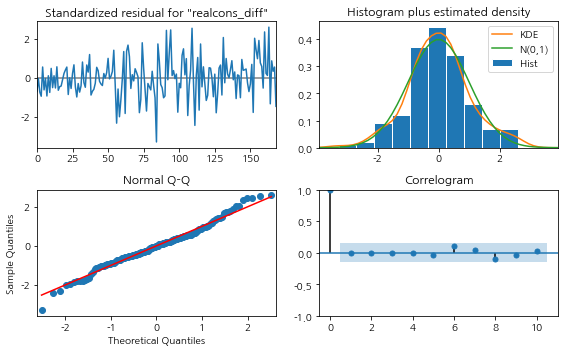

In [46]:
### realcons의 잔차 분석 시각화
model.plot_diagnostics(figsize=(8,5), variable=1)      ## 두번째 변수(variable=1)의 잔차분석

plt.tight_layout()
plt.show()

In [47]:
## 예측
pred = model.forecast(steps=len(test))
pred

,realgdp_diff,realcons_diff
169,38.242609,48.743375
170,69.984927,40.861588
171,55.845505,36.773027
172,56.287961,42.407064
173,55.324179,37.821631
174,55.085524,37.802063
175,53.322572,38.739355
176,54.140590,37.272147
177,53.137283,37.287069
178,52.871558,37.349544


In [57]:
### 역변환 ==> 차분 누적합(cumsum) + train 마지막 관측치

realgdp_real_pred = pred["realgdp_diff"].cumsum() + train["realgdp"].iloc[-1]
realcons_real_pred = pred["realcons_diff"].cumsum() + train["realcons"].iloc[-1]
realgdp_real_pred

169    11409.493609
170    11479.478535
171    11535.324040
172    11591.612001
173    11646.936180
174    11702.021704
175    11755.344276
176    11809.484866
177    11862.622149
178    11915.493707
179    11968.252552
180    12020.652059
181    12072.857073
182    12124.950557
183    12176.848143
184    12228.640214
185    12280.336891
186    12331.932022
187    12383.458484
188    12434.922531
189    12486.328841
190    12537.691709
191    12589.015398
192    12640.305179
193    12691.567654
194    12742.806088
195    12794.024116
196    12845.225189
197    12896.411576
198    12947.585556
199    12998.749080
200    13049.903637
201    13101.050615
Name: realgdp_diff, dtype: float64

In [60]:
### 인덱스 값 맞추기

realgdp_real_pred.index = test["realgdp"].index
realcons_real_pred.index = test["realcons"].index

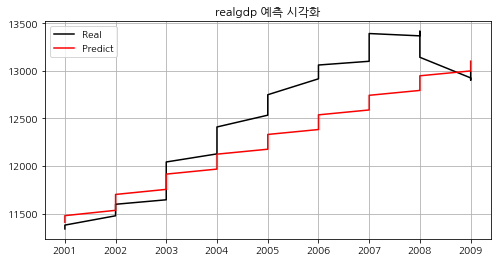

In [62]:
### 예측 시각화 (realgdp)

plt.figure(figsize=(8,4))

plt.title("realgdp 예측 시각화")
plt.plot(test["realgdp"], color="black", label="Real")
plt.plot(realgdp_real_pred, color="red", label="Predict")

plt.legend()
plt.grid()
plt.show()

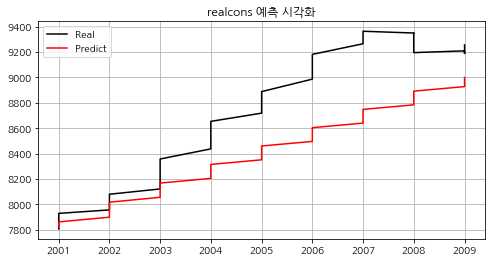

In [63]:
### 예측 시각화 (realcons)

plt.figure(figsize=(8,4))

plt.title("realcons 예측 시각화")
plt.plot(test["realcons"], color="black", label="Real")
plt.plot(realcons_real_pred, color="red", label="Predict")

plt.legend()
plt.grid()
plt.show()

In [67]:
## 성능평가 (MAE)
from sklearn.metrics import mean_absolute_error

realgdp_mae = mean_absolute_error(test["realgdp"], realgdp_real_pred)
realcons_mae = mean_absolute_error(test["realcons"], realcons_real_pred)

print(f"realgdp MAE : {realgdp_mae}")
print(f"realcons MAE : {realcons_mae}")

realgdp MAE : 294.8639955438724
realcons MAE : 325.8811734477157


In [70]:
## 성능평가 (MAPE)

realgdp_mape = np.mean(np.abs((test["realgdp"]-realgdp_real_pred)/test["realgdp"]))*100
realcons_mape = np.mean(np.abs((test["realcons"]-realcons_real_pred)/test["realcons"]))*100

print(f"realgdp MAPE : {realgdp_mape:.3f}%")
print(f"realcons MAPE : {realcons_mape:.3f}%")

realgdp MAPE : 2.292%
realcons MAPE : 3.621%


## <VARMA 모델>